1. 制作数据集
2. 构建模型、定义损失函数、定义优化器
3. 模型训练
4. 评估、参数调整

In [70]:
# 首先导入包
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import torchvision.models as models
# This is for the progress bar.
from tqdm import tqdm
import seaborn as sns

import torchmetrics
import torchkeras 

import logging

# 配置日志（级别、格式、输出位置）
logging.basicConfig(
    level=logging.ERROR,  # 日志级别：DEBUG < INFO < WARNING < ERROR < CRITICAL
    format="%(asctime)s - %(levelname)s - %(message)s",  # 日志格式
    # handlers=[
    #     logging.FileHandler("app.log"),  # 输出到文件
    #     logging.StreamHandler(),  # 同时输出到控制台
    # ],
)

# 记录不同级别的日志
logging.debug("这是调试信息（级别最低，默认不显示）")
logging.info("程序正常运行")
logging.warning("注意：可能存在风险")
logging.error("出错了！")
logging.critical("严重错误，程序可能崩溃")

2025-07-30 17:30:25,160 - ERROR - 出错了！
2025-07-30 17:30:25,161 - CRITICAL - 严重错误，程序可能崩溃


制作数据集

In [71]:
# 看看label文件长啥样
abs_path = os.path.abspath("./classify-leaves.ipynb")
print(abs_path)


# data/classify-leaves
data_dir = abs_path.split("实战")[0] + "data/classify-leaves/"
print(data_dir)

labels_dataframe = pd.read_csv(data_dir + "train.csv")
print(labels_dataframe.shape)
print(labels_dataframe.info())
print(labels_dataframe.describe())
print(labels_dataframe.head(5))


# 把label文件排个序
# 统计每个标签的出现次数，并按次数降序排列
label_counts = labels_dataframe["label"].value_counts()
# 提取排序后的标签列表（按出现次数从多到少）
leaves_labels = label_counts.index.tolist()
n_classes = len(leaves_labels)
print(n_classes)
print(leaves_labels[:10])
# 把label转成对应的数字
class_to_num = dict(zip(leaves_labels, range(n_classes)))
class_to_num
# 再转换回来，方便最后预测的时候使用
num_to_class = {v: k for k, v in class_to_num.items()}

/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/实战/c2/classify-leaves.ipynb
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/data/classify-leaves/
(18353, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18353 entries, 0 to 18352
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   18353 non-null  object
 1   label   18353 non-null  object
dtypes: object(2)
memory usage: 286.9+ KB
None
               image             label
count          18353             18353
unique         18353               176
top     images/0.jpg  maclura_pomifera
freq               1               353
          image             label
0  images/0.jpg  maclura_pomifera
1  images/1.jpg  maclura_pomifera
2  images/2.jpg  maclura_pomifera
3  images/3.jpg  maclura_pomifera
4  images/4.jpg  maclura_pomifera
176
['maclura_pomifera', 'ulmus_rubra', 'prunus_virginiana', 'acer_rubrum', 'broussonettia_papyrifera', 'prunus_sargentii', 'ptelea_trifoliata', 'ulmus

In [72]:
class LeavesDataset(Dataset):

    def __init__(
        self,
        csv_path,
        file_path,
        mode="train",
        valid_ratio=0.2,
        random_seed=42,  # 增加随机种子参数，保证结果可复现
    ):
        """
        Args:
            csv_path (string): csv 文件路径
            img_path (string): 图像文件所在路径
            mode (string): 训练模式还是测试模式
            valid_ratio (float): 验证集比例
            random_seed (int): 随机种子，用于确保划分结果可复现
        """

        self.file_path = file_path
        self.mode = mode

        # 读取CSV文件
        self.labels_dataframe = pd.read_csv(csv_path, header=0)
        self.data_length = len(self.labels_dataframe)

        # 计算训练集和验证集的大小
        self.train_length = int(self.data_length * (1 - valid_ratio))
        self.valid_length = self.data_length - self.train_length

        # 生成随机索引，实现随机划分
        # 设置随机种子，确保结果可复现
        np.random.seed(random_seed)
        # 生成0到data_length-1的随机排列索引
        shuffled_indices = np.random.permutation(self.data_length)

        # 根据模式选择相应的数据
        if self.mode == "train":
            # 训练集使用前train_length个随机索引
            train_indices = shuffled_indices[: self.train_length]
            self.image_array = self.labels_dataframe.iloc[train_indices, 0].values
            self.label_array = self.labels_dataframe.iloc[train_indices, 1].values
        elif self.mode == "valid":
            # 验证集使用剩余的随机索引
            valid_indices = shuffled_indices[self.train_length :]
            self.image_array = self.labels_dataframe.iloc[valid_indices, 0].values
            self.label_array = self.labels_dataframe.iloc[valid_indices, 1].values
        else:  # mode == "test"
            self.image_array = self.labels_dataframe.iloc[:, 0].values

        self.real_length = len(self.image_array)

        print(
            "Finished reading the {} set of Leaves Dataset ({} samples found)".format(
                mode, self.real_length
            )
        )

    def __len__(self):
        return self.real_length

    def __getitem__(self, index):
        image = self.image_array[index]
        label = self.label_array[index]
        logging.info(f"Processing image: {image}, label: {label}")
        image = Image.open(os.path.join(self.file_path, image)).convert("RGB")

        # 这里可以添加数据增强
        if self.mode == "train":
            transform = transforms.Compose(
                [
                    # 随机裁剪并缩放（比固定Resize更能模拟不同构图）
                    transforms.RandomResizedCrop(
                        224, scale=(0.8, 1.0)
                    ),  # 从原图80%-100%区域裁剪后缩放到224x224
                    # 随机水平翻转（保留，适合大部分对称场景）
                    transforms.RandomHorizontalFlip(p=0.5),
                    # 小角度旋转（应对轻微旋转偏差）
                    transforms.RandomRotation(degrees=(-15, 15)),
                    # 颜色抖动（模拟光照/色彩变化）
                    transforms.ColorJitter(
                        brightness=0.2,  # 亮度±20%
                        contrast=0.2,  # 对比度±20%
                        saturation=0.2,  # 饱和度±20%
                        hue=0.1,  # 色调±0.1（避免颜色失真）
                    ),
                    # 随机灰度化（降低对颜色的过度依赖）
                    transforms.RandomGrayscale(p=0.1),
                    # 随机高斯模糊（模拟图像模糊场景）
                    transforms.RandomApply(
                        [transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))],
                        p=0.1,
                    ),
                    # 转Tensor
                    transforms.ToTensor(),
                    # 标准化（使用ImageNet均值/标准差，适配预训练模型或加速收敛）
                    transforms.Normalize(
                        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                    ),
                    # # 随机擦除（模拟局部遮挡）
                    # transforms.RandomErasing(
                    #     p=0.2,
                    #     scale=(0.02, 0.33),  # 擦除区域占比
                    #     ratio=(0.3, 3.3),  # 擦除区域长宽比
                    # ),
                ]
            )
        else:
            # valid和test不做数据增强
            transform = transforms.Compose(
                [
                    transforms.Resize((224, 224)),
                    transforms.ToTensor(),
                    # 标准化（使用ImageNet均值/标准差，适配预训练模型或加速收敛）
                    transforms.Normalize(
                        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                    ),
                ]
            )
        image = transform(image)
        label = class_to_num[label]
        return image, label

In [73]:
train_path = data_dir + "train.csv"
test_path = data_dir + "test.csv"
# csv文件中已经images的路径了，因此这里只到上一级目录
img_path = data_dir

train_dataset = LeavesDataset(train_path, img_path, mode="train")
val_dataset = LeavesDataset(train_path, img_path, mode="valid")
test_dataset = LeavesDataset(test_path, img_path, mode="test")
print(train_dataset)
print(val_dataset)
print(test_dataset)

Finished reading the train set of Leaves Dataset (14682 samples found)
Finished reading the valid set of Leaves Dataset (3671 samples found)
Finished reading the test set of Leaves Dataset (8800 samples found)


In [74]:
batch_size = 128
# 定义data loader
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=5
)
val_loader = torch.utils.data.DataLoader(
    dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=5
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=5
)

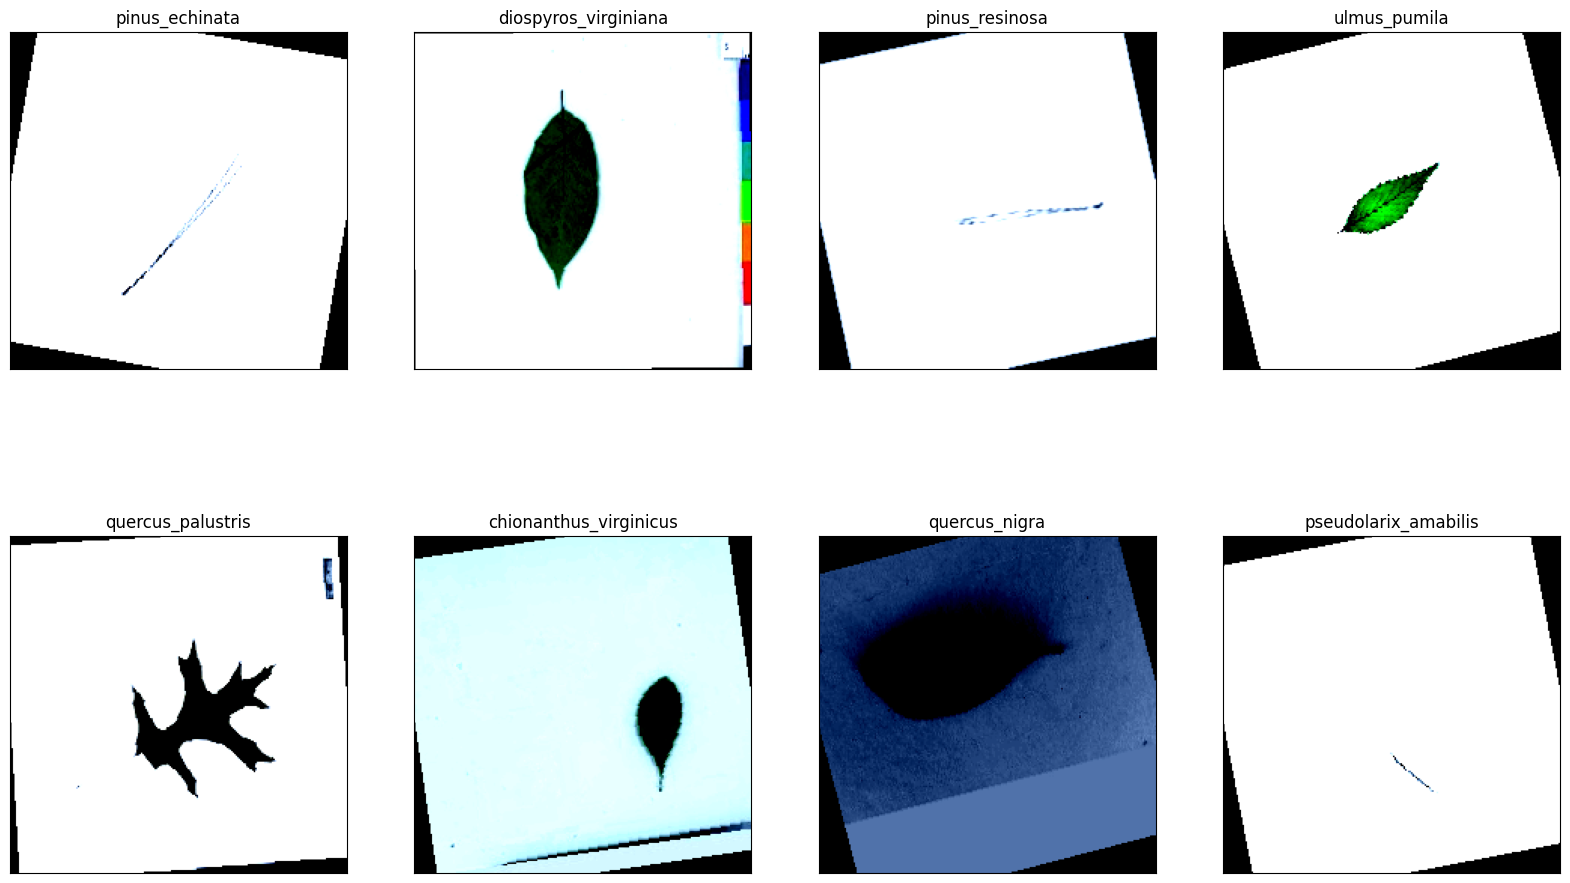

In [75]:
# 给大家展示一下数据长啥样
def im_convert(tensor):
    """展示数据"""

    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1, 2, 0)
    image = image.clip(0, 1)

    return image


fig = plt.figure(figsize=(20, 12))
rows = 2
columns = 4

dataiter = iter(train_loader)
inputs, classes = next(dataiter)

for idx in range(columns * rows):
    ax = fig.add_subplot(rows, columns, idx + 1, xticks=[], yticks=[])
    ax.set_title(num_to_class[int(classes[idx])])
    plt.imshow(im_convert(inputs[idx]))
plt.show()

构建模型

In [76]:
def get_net():
    num_to_class=176
    net=models.resnet18(pretrained=True)
    # 修改最后一层的输出为分类数
    net.fc = nn.Linear(net.fc.in_features, num_to_class)
    # 冻结非分类头的参数
    for param in net.parameters():
        param.requires_grad = False
    # 只训练分类头的参数
    for param in net.fc.parameters():
        param.requires_grad = True
    # 打印网络结构
    logging.info("Network structure:\n{}".format(net))
    return net


class Accuracy(nn.Module):
    def __init__(self):
        super().__init__()

        self.correct = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.total = nn.Parameter(torch.tensor(0.0), requires_grad=False)

    def forward(self, preds: torch.Tensor, targets: torch.Tensor):
        preds = preds.argmax(dim=-1)
        m = (preds == targets).sum()
        n = targets.shape[0]
        self.correct += m
        self.total += n

        return m / n

    def compute(self):
        return self.correct.float() / self.total

    def reset(self):
        self.correct -= self.correct
        self.total -= self.total

使用torchkeras进行模型训练、调参

<<<<<< ⚡️ cuda is used >>>>>>


/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


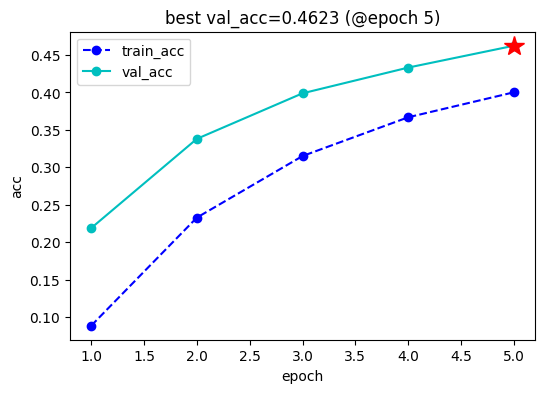

In [77]:
net = get_net().to("cuda" if torch.cuda.is_available() else "cpu")
lr, momentum, epochs = 0.001, 0.9, 5
ckpt_path = "checkpoint"
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

model = torchkeras.KerasModel(
    net,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    metrics_dict={"acc": Accuracy()},
    # lr_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(
    #     optimizer=optimizer, T_max=epochs, eta_min=3e-4
    # ),
)

# if gpu/mps is available, will auto use it, otherwise cpu will be used.
# model.load_ckpt(ckpt_path) #load trained ckpt and continue training
dfhistory = model.fit(
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    patience=5,
    monitor="val_acc",
    mode="max",
    ckpt_path=ckpt_path,
    plot=True,
)

模型性能评估

In [78]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

def evaluate_model(model, dataloader, device):
    """
    在指定数据集上评估模型，返回真实标签和预测标签
    Args:
        model: 训练好的模型
        dataloader: 验证集/测试集数据加载器
        device: 计算设备（cuda或cpu）
    Returns:
        true_labels: 真实标签列表
        pred_labels: 预测标签列表
    """
    model.eval()  # 切换到评估模式
    true_labels = []
    pred_labels = []

    with torch.no_grad():  # 关闭梯度计算，节省内存
        for images, labels in dataloader:
            # 数据移到设备上
            images = images.to(device)
            labels = labels.to(device)

            # 模型推理
            outputs = model(images)
            _, preds = torch.max(outputs, 1)  # 获取预测类别

            # 收集标签（移回CPU并转为numpy）
            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())

    return np.array(true_labels), np.array(pred_labels)


# --------------------------
# 3. 混淆矩阵可视化函数
# --------------------------
def plot_confusion_matrix(true_labels, pred_labels, class_names, save_path=None):
    """
    计算并绘制混淆矩阵
    Args:
        true_labels: 真实标签数组
        pred_labels: 预测标签数组
        class_names: 类别名称列表（与标签索引对应）
        save_path: 图像保存路径（None则直接显示）
    """
    # 计算混淆矩阵
    cm = confusion_matrix(true_labels, pred_labels)

    # 绘制热力图
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,  # 显示数值
        fmt="d",  # 数值格式为整数
        cmap="Blues",  # 颜色主题
        xticklabels=class_names,  # x轴标签（预测类别）
        yticklabels=class_names,  # y轴标签（真实类别）
    )
    plt.xlabel("预测类别", fontsize=12)
    plt.ylabel("真实类别", fontsize=12)
    plt.title("混淆矩阵", fontsize=15)

    # 保存或显示图像
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"混淆矩阵已保存至: {save_path}")
    else:
        plt.show()

In [ ]:
# 3. 加载模型和最优权重
best_model = model.load_ckpt(ckpt_path)
device = torch.device("cuda")

# 4. 在验证集上获取预测结果
true_labels, pred_labels = evaluate_model(best_model, val_loader, device)

# 5. 生成并显示混淆矩阵
plot_confusion_matrix(
    true_labels=true_labels,
    pred_labels=pred_labels,
    # class_names=class_names,
    save_path="./confusion_matrix.png"  # 可选：保存图像
)

AttributeError: 'NoneType' object has no attribute 'eval'